Script to download data from DMI.  We use the API from DMI whihc is described here:
https://www.dmi.dk/friedata/dokumentation/apis/climate-data-api-1




In [1]:
# required packages
import os
import requests
#from zipfile import ZipFile
#from io import BytesIO
#import xarray as xa
import json
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


In [2]:
url = 'https://opendataapi.dmi.dk/v2/climateData/collections/20kmGridValue/items?' \
    'datetime=2010-01-01T00:00:00%2B02:00/2026-01-01T00:00:00%2B02:00' \
    '&parameterId=mean_temp' \
    '&timeResolution=month'
response = requests.get(url, timeout=30)
print(response.status_code)

200


In [3]:
# extract API response to JSON data object
response.status_code
data = response.json()
print(data['features'][1])

{'type': 'Feature', 'id': '1f66eb44-4bef-0ca5-0f26-82e1bf9ca88d', 'geometry': {'type': 'Polygon', 'coordinates': [[[11.2101, 55.3863], [11.5255, 55.3802], [11.537, 55.5597], [11.2201, 55.5659], [11.2101, 55.3863]]]}, 'properties': {'parameterId': 'mean_temp', 'qcStatus': 'manual', 'created': '2026-05-20T01:18:50+00:00', 'timeResolution': 'month', 'from': '2025-12-01T00:00:00.001000+01:00', 'to': '2026-01-01T00:00:00+01:00', 'cellId': '20km_614_64', 'value': 5.1, 'calculatedAt': '2026-05-20T00:51:05.884000'}}


In [4]:
# create geodateframe with GeoPandas
geo_data = gpd.GeoDataFrame.from_features(data['features'])
print(geo_data[:5])

                                            geometry parameterId qcStatus  \
0  POLYGON ((10.9032 55.5712, 11.2201 55.5659, 11...   mean_temp   manual   
1  POLYGON ((11.2101 55.3863, 11.5255 55.3802, 11...   mean_temp   manual   
2  POLYGON ((11.2201 55.5659, 11.537 55.5597, 11....   mean_temp   manual   
3  POLYGON ((11.4807 54.6619, 11.7904 54.6552, 11...   mean_temp   manual   
4  POLYGON ((10.3369 57.5554, 10.671 57.5514, 10....   mean_temp   manual   

                     created timeResolution                              from  \
0  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
1  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
2  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
3  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
4  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   

                          to       cellId  value  

In [17]:
# add column with month, year

def translate_time(from_time):
    '''
    Function translates from_time in the ISO 8601 international standard formate to month as
    three letter string and year as str

    Arg:
        from_time: (str) time data in ISO 8601 formate
    '''
    
    months = {'01':'JAN', '02':'FEB', '03':'MAR', '04':'APR', '05':'MAY', '06':'JUN', '07':'JUL', 
              '08':'AUG', '09':'SEP', '10':'OCT', '11':'NOV', '12':'DEC'}

    from_time_as_list = from_time.split('-')

    year = from_time_as_list[0]
    month = months[from_time_as_list[1]]
    
    return year, month

# test
print(translate_time('2026-01-01T00:00:00+01:00'))

# Adding year and data as column
geo_data = geo_data.assign(Year = [translate_time(time_from)[0] for time_from in geo_data['from']],
                        Month = [translate_time(time_from)[1] for time_from in geo_data['from']])

('2026', 'JAN')


In [18]:
geo_data[:5]

,geometry,parameterId,qcStatus,created,timeResolution,from,to,cellId,value,calculatedAt,Year,Month
0,"POLYGON ((10.9032 55.5712, 11.2201 55.5659, 11...",mean_temp,manual,2026-05-20T01:18:50+00:00,month,2025-12-01T00:00:00.001000+01:00,2026-01-01T00:00:00+01:00,20km_616_62,5.7,2026-05-20T00:51:05.884000,2025,DEC
1,"POLYGON ((11.2101 55.3863, 11.5255 55.3802, 11...",mean_temp,manual,2026-05-20T01:18:50+00:00,month,2025-12-01T00:00:00.001000+01:00,2026-01-01T00:00:00+01:00,20km_614_64,5.1,2026-05-20T00:51:05.884000,2025,DEC
2,"POLYGON ((11.2201 55.5659, 11.537 55.5597, 11....",mean_temp,manual,2026-05-20T01:18:50+00:00,month,2025-12-01T00:00:00.001000+01:00,2026-01-01T00:00:00+01:00,20km_616_64,5.2,2026-05-20T00:51:05.884000,2025,DEC
3,"POLYGON ((11.4807 54.6619, 11.7904 54.6552, 11...",mean_temp,manual,2026-05-20T01:18:50+00:00,month,2025-12-01T00:00:00.001000+01:00,2026-01-01T00:00:00+01:00,20km_606_66,5.3,2026-05-20T00:51:05.884000,2025,DEC
4,"POLYGON ((10.3369 57.5554, 10.671 57.5514, 10....",mean_temp,manual,2026-05-20T01:18:50+00:00,month,2025-12-01T00:00:00.001000+01:00,2026-01-01T00:00:00+01:00,20km_638_58,6.2,2026-05-20T00:51:05.884000,2025,DEC


Text(0.5, 1.0, 'Mean temperature December 2025')

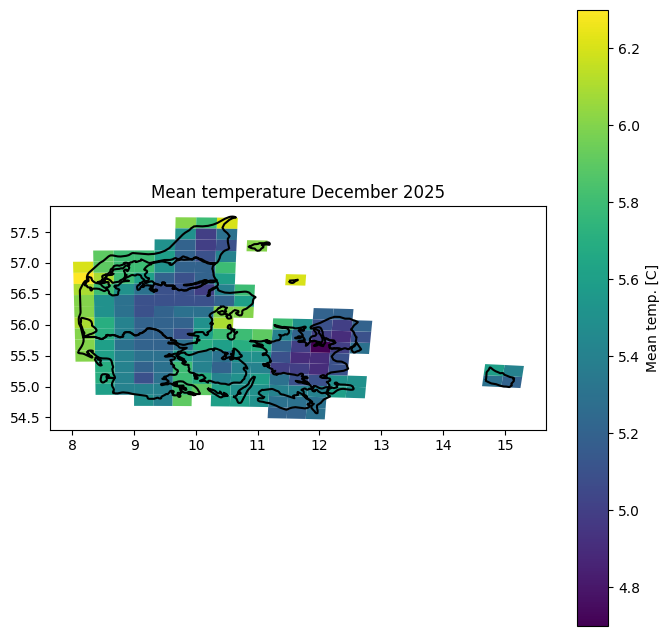

In [60]:
# Mean temperatures for december 2025
geo_data_dec_2025 = geo_data[(geo_data["Year"] == "2025") & (geo_data["Month"] == "DEC")]

# Import DK
dk = gpd.GeoDataFrame.from_file('dk.json')

# Plot
fig, ax = plt.subplots(figsize=(8,8))
dk.boundary.plot(ax=ax, color='k')
geo_data_dec_2025.plot(ax=ax, column='value', legend=True, legend_kwds={'label':'Mean temp. [C]'})

ax.set_title('Mean temperature December 2025')